<a href="https://colab.research.google.com/github/vijayasrimurugan5-ui/STATISTICAL_DATA_ANALYSIS_USING_RESTAURANT_DATASET/blob/main/STATISTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1=pd.read_csv('/content/drive/MyDrive/717824I363/datasets/i1.csv')
df2=pd.read_csv('/content/drive/MyDrive/717824I363/datasets/i2.csv')

In [3]:
df=df1.merge(df2,how='outer')

In [4]:
df.shape

(15621, 16)

In [5]:
df.head()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.0,315.0,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN


In [6]:
df.describe()

,Invoice No.,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Covers,HSN
count,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15613.000000,15621.0,0.0
mean,25989.963127,116.608988,1.338839,147.407080,1.262818,7.303668,153.447930,18.068340,0.0,NaN
std,1433.192998,63.663769,0.949814,210.127442,6.656396,10.461474,219.678163,17.191377,0.0,NaN
min,23465.000000,12.000000,1.000000,12.000000,0.000000,0.000000,12.600000,1.000000,0.0,NaN
25%,24751.000000,50.000000,1.000000,80.000000,0.000000,4.000000,84.000000,4.000000,0.0,NaN
50%,25980.000000,140.000000,1.000000,150.000000,0.000000,7.000000,147.000000,12.000000,0.0,NaN
75%,27274.000000,160.000000,1.000000,170.000000,0.000000,8.500000,178.500000,26.000000,0.0,NaN
max,28389.000000,770.000000,28.000000,21560.000000,288.000000,1078.000000,22638.000000,50.000000,0.0,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [8]:
df.isnull().sum()

,0
Date,0
Timestamp,0
Invoice No.,0
Item Name,0
Price,0
Qty.,0
Sub Total,0
Discount,0
Tax,0
Final Total,0


In [9]:
df=df.drop(['Table No.','Server Name','Covers','Variation','HSN'],axis=1)

In [10]:
a=df['Final Total'].sum()
print(a)

2397010.12


In [12]:
b=df['Invoice No.'].nunique()
print(b)

4925


In [15]:
df['Invoice No.'].count()

np.int64(15621)

In [13]:
avg=a/b
print(avg)

486.70256243654825


In [16]:
v=df.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]

<Axes: xlabel='Item Name'>

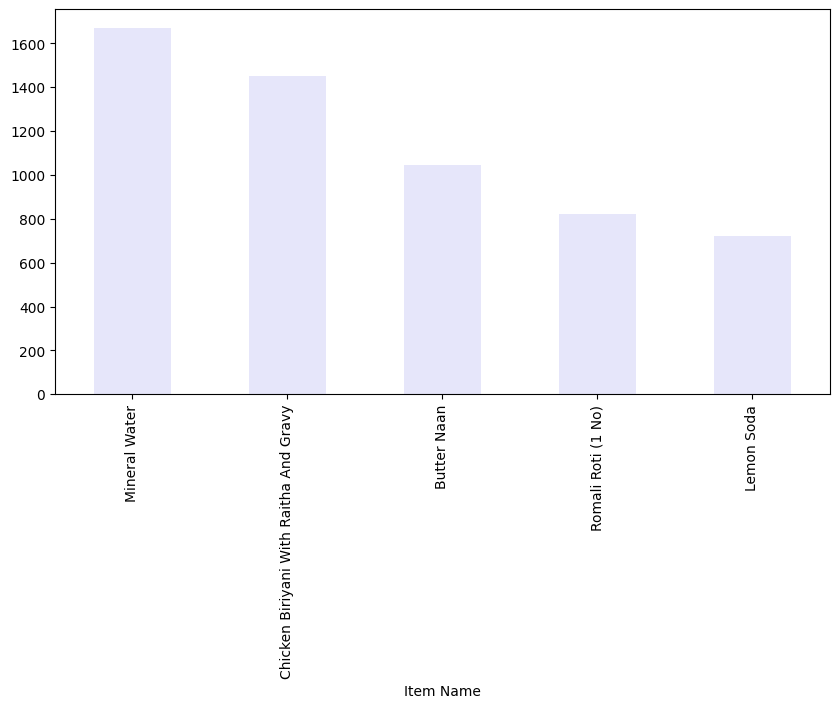

In [17]:
df.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(10,5),color='lavender')

<Axes: xlabel='Item Name', ylabel='Qty.'>

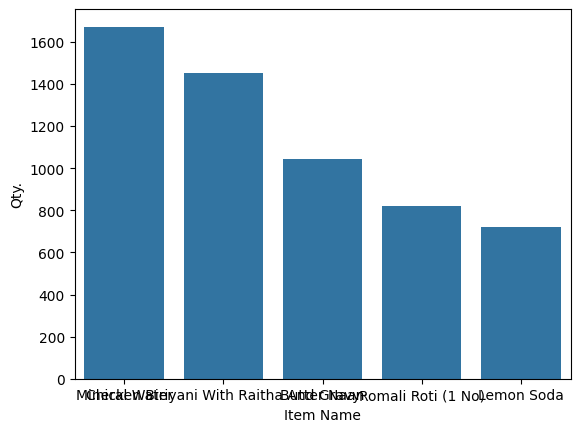

In [18]:
sns.barplot(v)

In [19]:
v=df.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False)[0:5]

<Axes: xlabel='Item Name', ylabel='Final Total'>

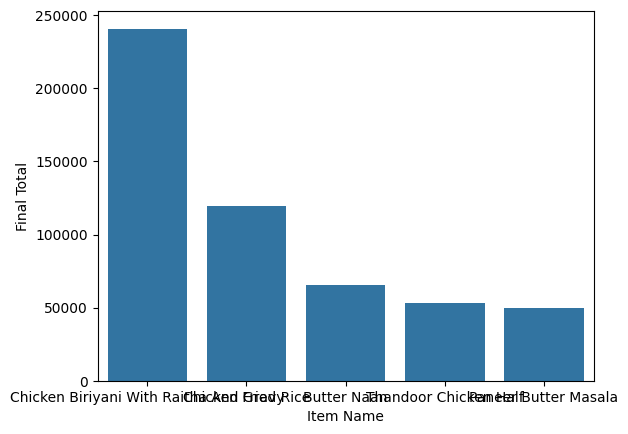

In [20]:
sns.barplot(v)

In [21]:
df[df['Date']=='2023-09-15']['Final Total'].sum()

np.float64(21042.02)

In [22]:
df.groupby('Date')['Final Total'].sum().loc["2023-09-15"]

np.float64(21042.02)

In [23]:
df[(df['Date'] == '2023-09-15') &
   (df['Item Name'] == 'Chicken Noodles')]['Qty.'].sum()

np.float64(7.0)

In [25]:
invoice_totals = df.groupby('Invoice No.')['Final Total'].sum()
v = invoice_totals[invoice_totals > 2000]
print(v)

Invoice No.
23499     2533.64
23508     2011.00
23637     5644.82
23718     3517.50
23827    22638.00
           ...   
28014     3013.68
28126     2887.50
28145     4078.68
28259     4291.36
28315     2004.44
Name: Final Total, Length: 162, dtype: float64


In [24]:
df[df['Final Total']==2887.50]['Invoice No.']

,Invoice No.
14772,28126


In [26]:
df[df['Invoice No.'] == 28145][
    ['Item Name', 'Qty.', 'Final Total']
].sum()

,0
Item Name,Butter Chicken GravyButter Chicken GravyButter...
Qty.,40.0
Final Total,4078.68


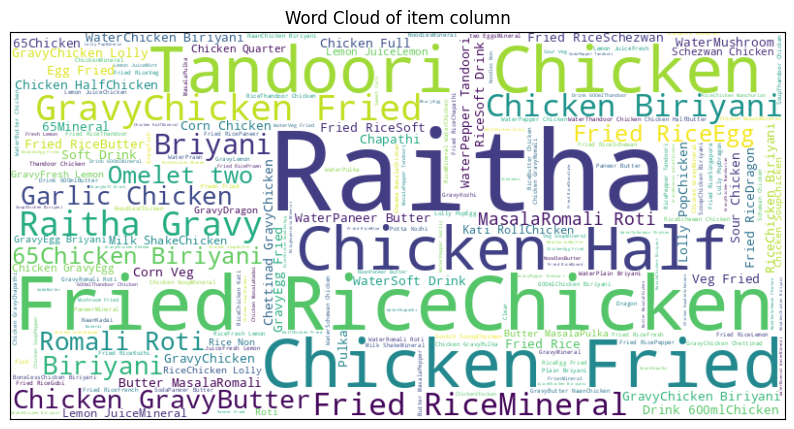

In [27]:
from wordcloud import WordCloud
text=''.join(df['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color='white',width=800,height=400).generate(text)
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bilinear')
ax.set_title('Word Cloud of item column')
ax.set_xticks([])
ax.set_yticks([])
plt.show()